<a id='1-setup-and-data-loading'></a>
## 1. Setup and Data Loading

### 1.1 Libraries and Configuration

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
 )
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
TARGET = "Injury_Next_Season"

### 1.2 Load Dataset

In [16]:
data_path = Path("data.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 800 rows x 19 columns


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [17]:
df.sample(5, random_state=RANDOM_STATE)

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
696,20,177,83,Defender,11.651417,21,2,72.961965,76.010591,250.239484,84.437347,5.809211,74.922934,7.026939,61.906446,86.943814,1,1,26.493026
667,23,183,74,Forward,10.679324,17,0,72.749380,83.240448,239.586454,83.229296,5.485104,65.473997,7.133319,64.484729,75.227116,0,1,22.096808
63,20,183,76,Goalkeeper,9.999682,10,3,71.268829,71.034240,266.125782,85.041696,5.768755,83.852043,6.996332,48.937422,70.744827,0,1,22.694019
533,20,169,73,Goalkeeper,8.122849,10,2,79.070492,90.636618,255.957157,88.544164,6.323186,82.042122,8.418339,60.147325,86.586818,1,0,25.559329
66,24,183,71,Forward,5.801271,37,3,64.023593,78.797275,275.453325,72.062097,5.623286,67.946307,7.650424,64.848743,69.549424,0,1,21.200991


<a id='2-data-quality-and-exploratory-analysis'></a>
## 2. Data Quality and Exploratory Analysis

In [18]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df[TARGET].value_counts().rename_axis(TARGET).to_frame("count"))
display(
    (
        df[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename_axis(TARGET)
        .to_frame("percentage")
    )
)

Column names:
['Age', 'Height_cm', 'Weight_kg', 'Position', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI']

Data types:


,dtype
Age,int64
Height_cm,int64
Weight_kg,int64
Position,str
Training_Hours_Per_Week,float64
Matches_Played_Past_Season,int64
Previous_Injury_Count,int64
Knee_Strength_Score,float64
Hamstring_Flexibility,float64
Reaction_Time_ms,float64



Target distribution:


,count
Injury_Next_Season,
0,400
1,400


,percentage
Injury_Next_Season,
0,50.0
1,50.0


In [19]:
quality_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }
).sort_values(["missing_count", "n_unique"], ascending=[False, True])

print(f"Duplicate rows: {df.duplicated().sum()}")
display(quality_summary)

Duplicate rows: 0


,missing_count,missing_pct,n_unique
Warmup_Routine_Adherence,0,0.0,2
Injury_Next_Season,0,0.0,2
Position,0,0.0,4
Age,0,0.0,7
Previous_Injury_Count,0,0.0,9
Matches_Played_Past_Season,0,0.0,35
Height_cm,0,0.0,42
Weight_kg,0,0.0,53
BMI,0,0.0,538
Training_Hours_Per_Week,0,0.0,781


In [20]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,800.0,NaN,NaN,NaN,21.135,1.991037,18.0,19.0,21.0,23.0,24.0
Height_cm,800.0,NaN,NaN,NaN,177.4075,7.148974,154.0,173.0,177.0,182.0,200.0
Weight_kg,800.0,NaN,NaN,NaN,73.235,9.929276,45.0,66.0,73.0,80.0,105.0
Position,800,4,Midfielder,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Training_Hours_Per_Week,800.0,NaN,NaN,NaN,9.95115,2.610395,5.0,8.127151,9.89571,11.53514,18.866608
Matches_Played_Past_Season,800.0,NaN,NaN,NaN,22.3325,10.311516,5.0,13.0,22.0,32.0,39.0
Previous_Injury_Count,800.0,NaN,NaN,NaN,1.53625,1.292584,0.0,1.0,1.0,2.0,8.0
Knee_Strength_Score,800.0,NaN,NaN,NaN,74.933249,6.672704,52.391351,70.432656,74.997933,79.632391,93.900051
Hamstring_Flexibility,800.0,NaN,NaN,NaN,79.154123,6.782332,58.180381,74.495959,79.187909,83.813179,100.0
Reaction_Time_ms,800.0,NaN,NaN,NaN,249.423244,22.532387,180.0,234.089585,249.127328,265.105082,306.730851


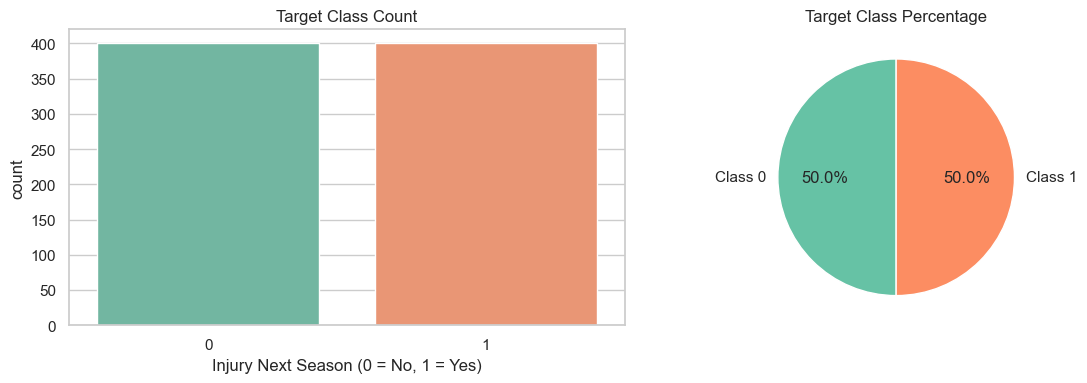

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=TARGET, ax=ax[0], hue=TARGET, palette="Set2", legend=False)
ax[0].set_title("Target Class Count")
ax[0].set_xlabel("Injury Next Season (0 = No, 1 = Yes)")

target_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
ax[1].pie(
    target_pct,
    labels=[f"Class {idx}" for idx in target_pct.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", 2),
)
ax[1].set_title("Target Class Percentage")

plt.tight_layout()
plt.show()

,injury_rate,players
Position,,
Forward,54.31%,197
Midfielder,50.23%,213
Defender,48.53%,204
Goalkeeper,46.77%,186


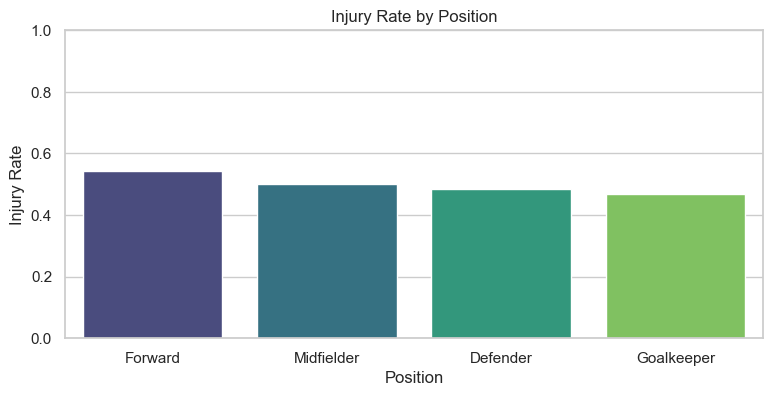

In [22]:
position_risk = (
    df.groupby("Position")[TARGET]
    .agg(["mean", "count"])
    .rename(columns={"mean": "injury_rate", "count": "players"})
    .sort_values("injury_rate", ascending=False)
)

display(position_risk.style.format({"injury_rate": "{:.2%}"}))

plt.figure(figsize=(9, 4))
sns.barplot(
    data=position_risk.reset_index(),
    x="Position",
    y="injury_rate",
    hue="Position",
    palette="viridis",
    legend=False,
    order=position_risk.index.tolist(),
)
plt.title("Injury Rate by Position")
plt.ylabel("Injury Rate")
plt.ylim(0, 1)
plt.show()

,corr_with_target
Stress_Level_Score,0.529961
Sleep_Hours_Per_Night,-0.510869
Balance_Test_Score,-0.494814
Sprint_Speed_10m_s,-0.471499
Reaction_Time_ms,0.470878
Knee_Strength_Score,-0.454551
Hamstring_Flexibility,-0.450317
Nutrition_Quality_Score,-0.412496
Agility_Score,-0.393681
Previous_Injury_Count,0.382226


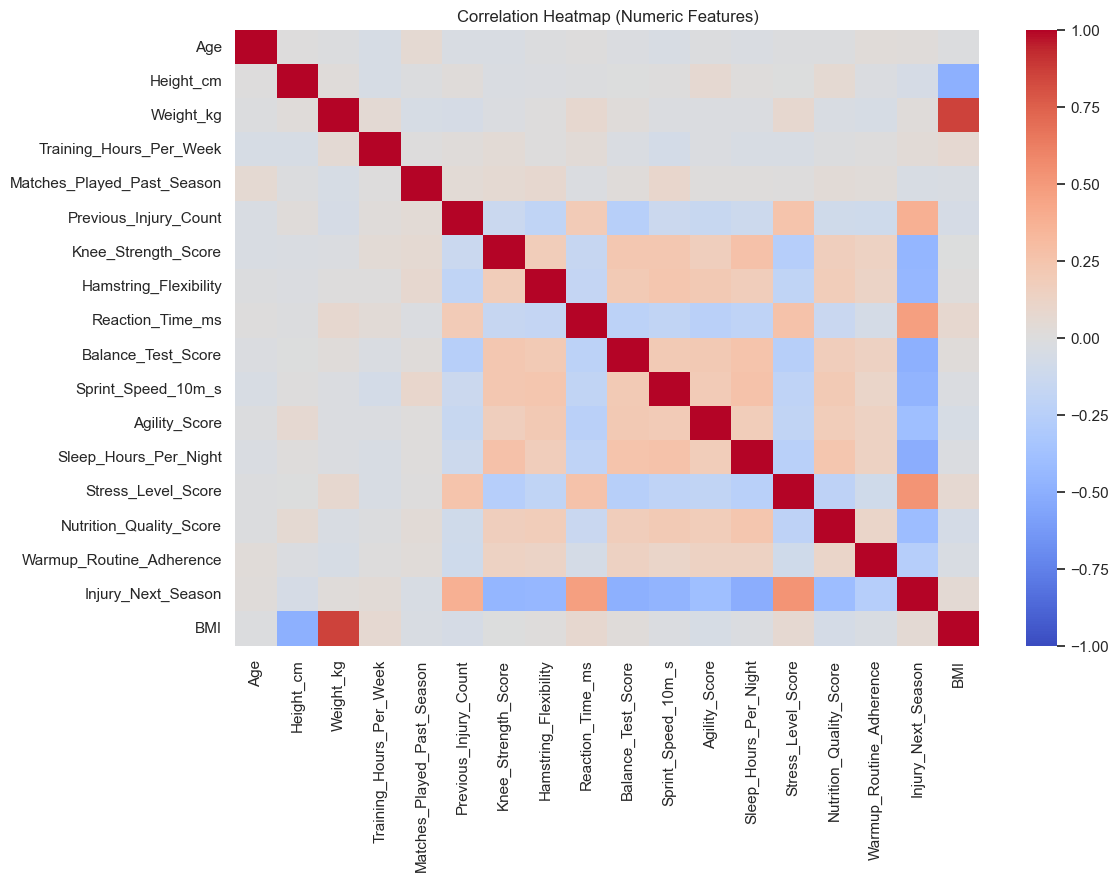

In [23]:
numeric_df = df.select_dtypes(include=["number"]).copy()
corr_with_target = (
    numeric_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

display(corr_with_target.to_frame("corr_with_target").head(12))

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

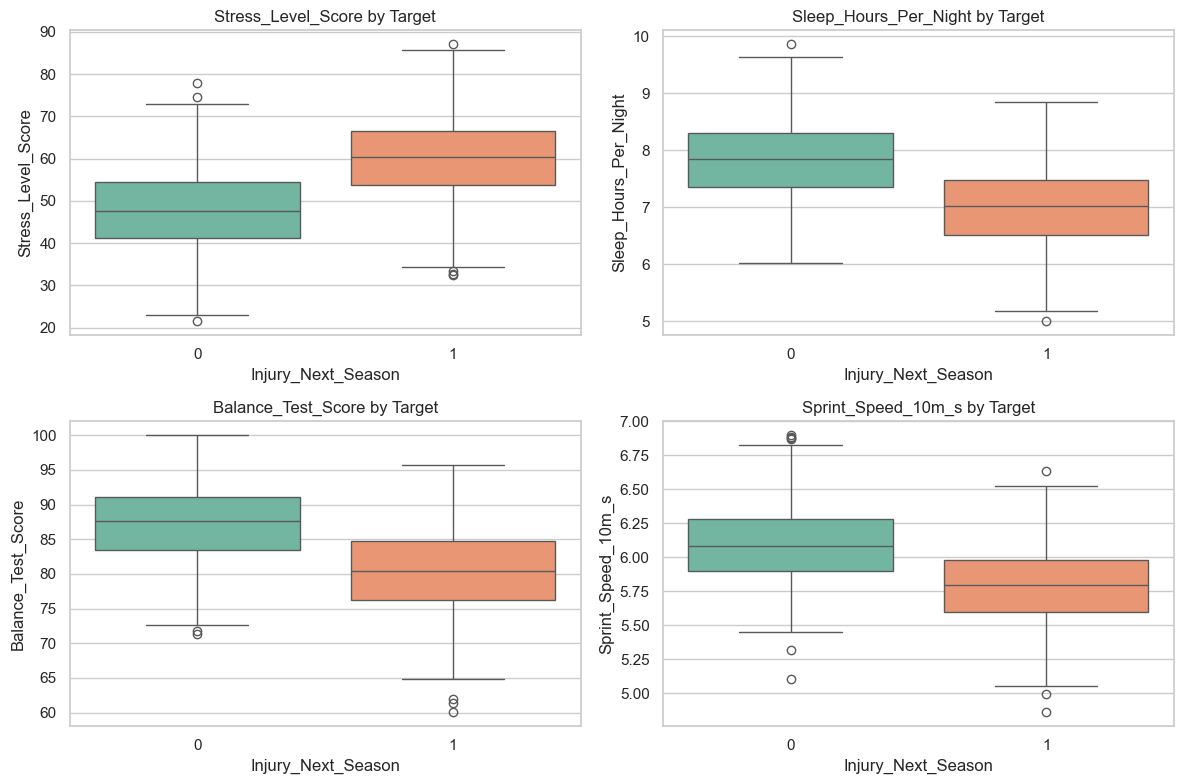

In [24]:
top_features = corr_with_target.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    sns.boxplot(data=df, x=TARGET, y=feature, ax=ax, hue=TARGET, palette="Set2", legend=False)
    ax.set_title(f"{feature} by Target")

plt.tight_layout()
plt.show()

In [25]:
def add_engineered_features(input_df: pd.DataFrame) -> pd.DataFrame:
    df_out = input_df.copy()
    df_out["Workload_Index"] = (
        df_out["Training_Hours_Per_Week"] * df_out["Matches_Played_Past_Season"]
    )
    df_out["Recovery_Balance"] = (
        df_out["Sleep_Hours_Per_Night"] - (df_out["Stress_Level_Score"] / 20.0)
    )
    df_out["Strength_Flexibility_Ratio"] = (
        df_out["Knee_Strength_Score"] / np.clip(df_out["Hamstring_Flexibility"], 1e-6, None)
    )
    return df_out

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train_eng = add_engineered_features(X_train)
X_test_eng = add_engineered_features(X_test)

print("Train shape:", X_train_eng.shape)
print("Test shape:", X_test_eng.shape)

Train shape: (640, 21)
Test shape: (160, 21)


In [26]:
def evaluate_logistic_cv(X_input: pd.DataFrame, y_input: pd.Series) -> dict:
    numeric_features = X_input.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_input.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        model,
        X_input,
        y_input,
        cv=cv,
        scoring={"roc_auc": "roc_auc", "f1": "f1"},
        n_jobs=-1,
    )

    return {
        "roc_auc": scores["test_roc_auc"].mean(),
        "f1": scores["test_f1"].mean(),
    }

raw_scores = evaluate_logistic_cv(X_train, y_train)
eng_scores = evaluate_logistic_cv(X_train_eng, y_train)

comparison = pd.DataFrame(
    [raw_scores, eng_scores], index=["Raw features", "Engineered features"]
).round(4)

display(comparison)

,roc_auc,f1
Raw features,0.9893,0.9393
Engineered features,0.9891,0.9393


In [27]:
numeric_features = X_train_eng.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_eng.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Candidate models:", list(models.keys()))

Numeric features: 20
Categorical features: 1
Candidate models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'KNN']


<a id='4-feature-selection'></a>
## 4. Feature Selection

,feature,mutual_info
0,Recovery_Balance,0.285013
1,Balance_Test_Score,0.177981
2,Stress_Level_Score,0.170138
3,Sleep_Hours_Per_Night,0.153107
4,Sprint_Speed_10m_s,0.147885
5,Reaction_Time_ms,0.139684
6,Agility_Score,0.088937
7,Knee_Strength_Score,0.087523
8,Hamstring_Flexibility,0.078328
9,Nutrition_Quality_Score,0.074499


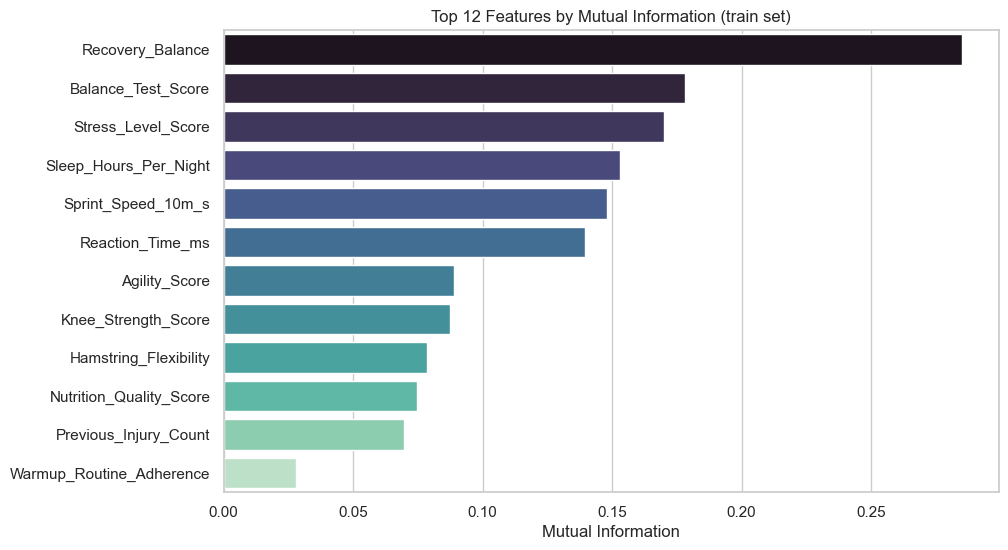

In [28]:
X_train_dummies = pd.get_dummies(X_train_eng, drop_first=True)
mi_scores = mutual_info_classif(X_train_dummies, y_train, random_state=RANDOM_STATE)

mi_df = (
    pd.DataFrame({"feature": X_train_dummies.columns, "mutual_info": mi_scores})
    .sort_values("mutual_info", ascending=False)
    .reset_index(drop=True)
)

display(mi_df.head(12))

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(12), x="mutual_info", y="feature", hue="feature", palette="mako", legend=False)
plt.title("Top 12 Features by Mutual Information (train set)")
plt.xlabel("Mutual Information")
plt.ylabel("")
plt.show()

<a id='5-model-training-and-selection'></a>
## 5. Model Training and Selection

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

results = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    scores = cross_validate(
        pipeline,
        X_train_eng,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    results.append(
        {
            "Model": model_name,
            **{metric: scores[f"test_{metric}"].mean() for metric in scoring},
        }
    )

cv_results = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(cv_results.round(4))

,Model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9391,0.9358,0.9438,0.9393,0.9891
1,KNN,0.9422,0.9580,0.9250,0.9410,0.9858
2,Gradient Boosting,0.9219,0.9302,0.9125,0.9210,0.9802
3,Random Forest,0.9203,0.9273,0.9125,0.9196,0.9802


In [30]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = models[best_model_name]

final_pipeline = Pipeline(steps=[("prep", preprocessor), ("model", best_model)])
final_pipeline.fit(X_train_eng, y_train)

y_pred = final_pipeline.predict(X_test_eng)
y_proba = final_pipeline.predict_proba(X_test_eng)[:, 1]

print(f"Best model selected: {best_model_name}")

Best model selected: Logistic Regression


<a id='6-final-evaluation-and-interpretation'></a>
## 6. Final Evaluation and Interpretation

,metric,value
0,accuracy,0.9750
1,precision,0.9872
2,recall,0.9625
3,f1,0.9747
4,roc_auc,0.9969


Classification report:
              precision    recall  f1-score   support

           0     0.9634    0.9875    0.9753        80
           1     0.9872    0.9625    0.9747        80

    accuracy                         0.9750       160
   macro avg     0.9753    0.9750    0.9750       160
weighted avg     0.9753    0.9750    0.9750       160



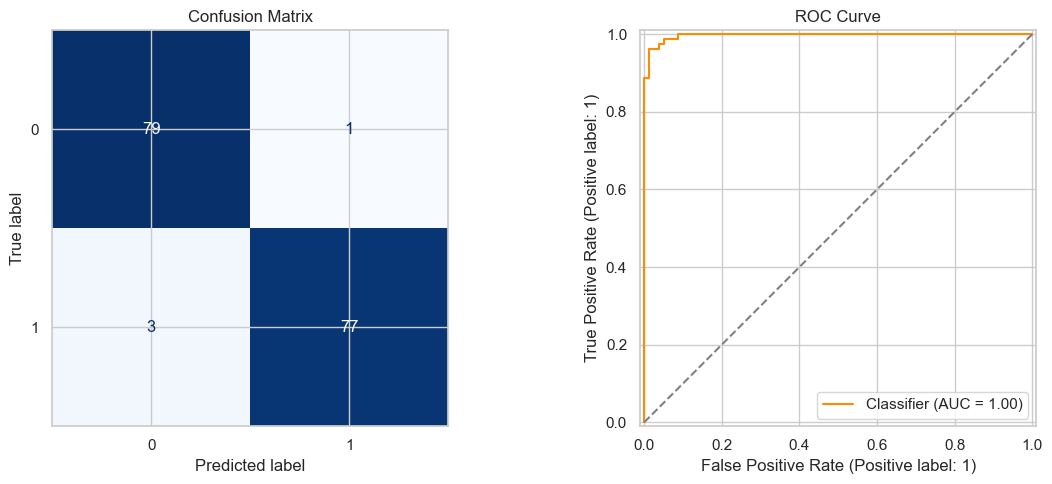

In [31]:
test_metrics = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_proba),
        ],
    }
)
display(test_metrics.round(4))

print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="darkorange")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

,feature,importance_mean
0,Reaction_Time_ms,0.018156
1,Sprint_Speed_10m_s,0.013320
2,Knee_Strength_Score,0.011820
3,Balance_Test_Score,0.010000
4,Hamstring_Flexibility,0.009852
5,Stress_Level_Score,0.008734
6,Nutrition_Quality_Score,0.008273
7,Recovery_Balance,0.007977
8,Previous_Injury_Count,0.004562
9,Sleep_Hours_Per_Night,0.003156


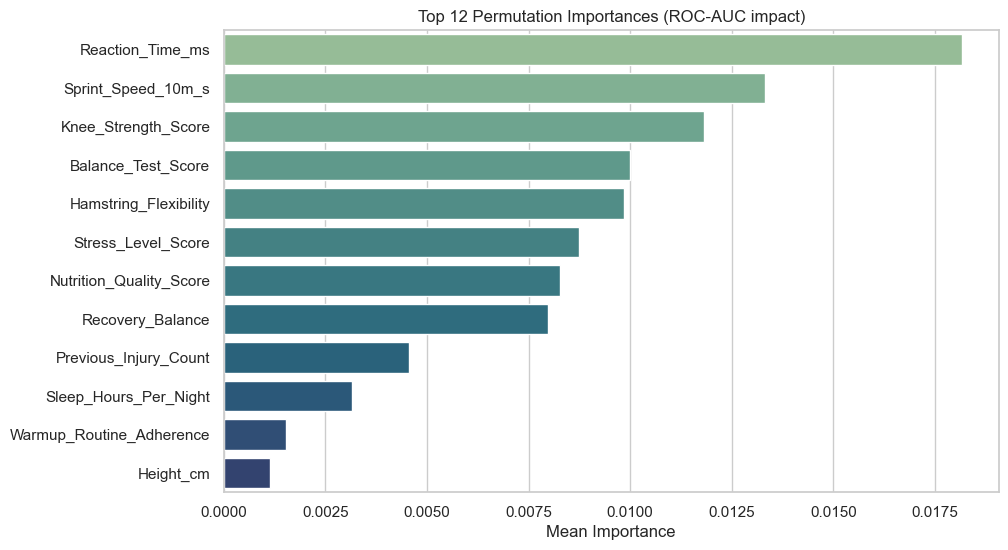

,count
error_type,
Correct,156
False Negative,3
False Positive,1


In [33]:
perm_result = permutation_importance(
    final_pipeline,
    X_test_eng,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

importance_df = (
    pd.DataFrame(
        {
            "feature": X_test_eng.columns,
            "importance_mean": perm_result.importances_mean,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(12))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(12),
    x="importance_mean",
    y="feature",
    hue="feature",
    palette="crest",
    legend=False,
    orient="h",
)
plt.title("Top 12 Permutation Importances (ROC-AUC impact)")
plt.xlabel("Mean Importance")
plt.ylabel("")
plt.show()

error_analysis = X_test_eng.copy()
error_analysis["actual"] = y_test.values
error_analysis["pred"] = y_pred
error_analysis["pred_proba"] = y_proba
error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 1) & (error_analysis["pred"] == 0),
        (error_analysis["actual"] == 0) & (error_analysis["pred"] == 1),
    ],
    ["False Negative", "False Positive"],
    default="Correct",
)

display(error_analysis["error_type"].value_counts().to_frame("count"))

<a id='7-model-export'></a>
## 7. Model Export

In [34]:
artifact = {
    "pipeline": final_pipeline,
    "target_name": TARGET,
    "feature_columns": X_train_eng.columns.tolist(),
    "model_name": best_model_name,
}

joblib.dump(artifact, "injury_prediction_pipeline.joblib")
print("Saved: injury_prediction_pipeline.joblib")

Saved: injury_prediction_pipeline.joblib
